# DSA210: Machine Learning & Benchmark Analysis
## Personal CS2 Gameplay vs. Professional Standards
This notebook contains the complete pipeline for Data Loading, Exploratory Data Analysis, Hypothesis Testing, and Machine Learning.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")


## 1. Data Loading and Preprocessing
Here we load the personal and professional datasets and combine them into a single dataframe.


In [2]:
# Load data
personal_df = pd.read_csv('personal_cs2_data.csv')
pro_df = pd.read_csv('professional_cs2_data.csv')

# Combine into single DataFrame
df = pd.concat([personal_df, pro_df], ignore_index=True)

# Pre-processing for EDA and Hypothesis
df_kill = df[df['Headshot_Kill'] != -1]
df_entry = df[df['Entry_Attempt'] == 1]

df.head()


,Match_ID,Round_Num,Economy_State,Utility_Damage,Headshot_Kill,Entry_Attempt,Entry_Success,Round_Won,Player_Level
0,1,1,Full Buy,16.317026,-1,0,-1,1,Personal
1,1,2,Full Buy,22.579151,-1,1,0,1,Personal
2,1,3,Full Buy,23.236647,1,1,0,1,Personal
3,1,4,Eco,23.771005,1,1,0,0,Personal
4,1,5,Full Buy,15.919078,0,1,0,0,Personal


## 2. Exploratory Data Analysis (EDA)
Visualizing key differences between Personal and Professional gameplay.


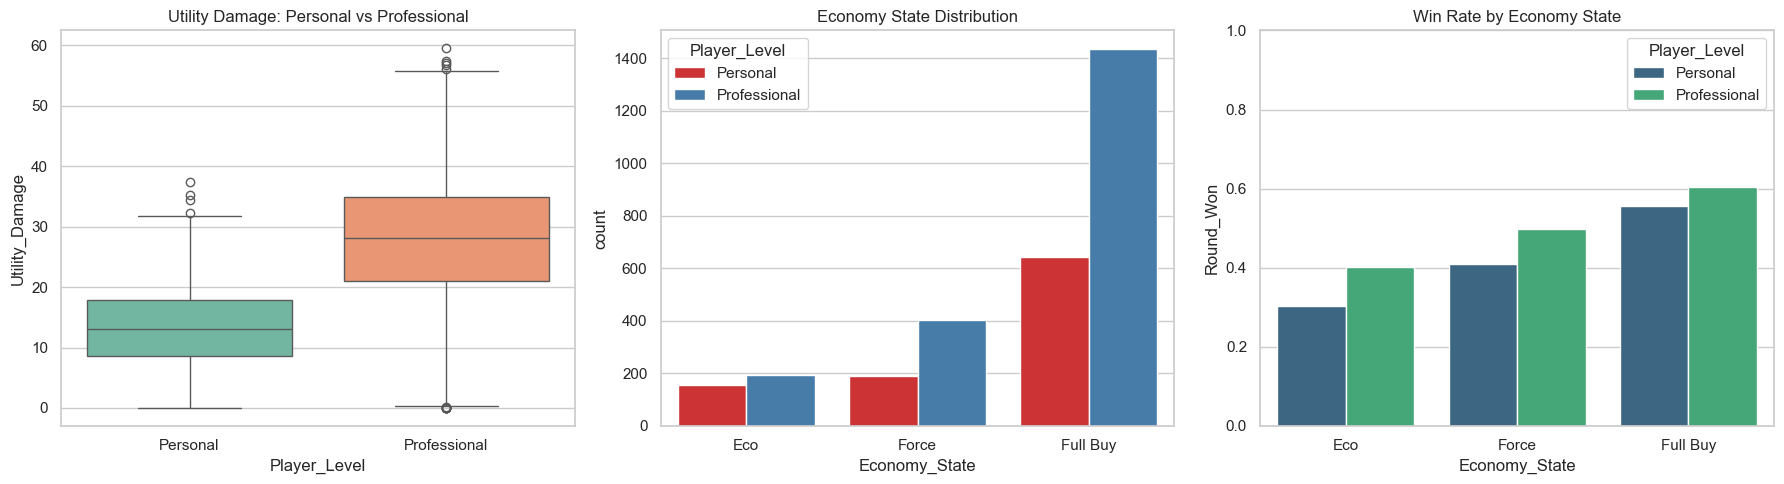

In [3]:
plt.figure(figsize=(18, 5))

# Plot 1: Utility Damage
plt.subplot(1, 3, 1)
sns.boxplot(x='Player_Level', y='Utility_Damage', data=df, palette='Set2')
plt.title('Utility Damage: Personal vs Professional')

# Plot 2: Economy Breakdown
plt.subplot(1, 3, 2)
sns.countplot(x='Economy_State', hue='Player_Level', data=df, palette='Set1', order=['Eco', 'Force', 'Full Buy'])
plt.title('Economy State Distribution')

# Plot 3: Win Rate by Economy
plt.subplot(1, 3, 3)
win_rates = df.groupby(['Player_Level', 'Economy_State'])['Round_Won'].mean().reset_index()
sns.barplot(x='Economy_State', y='Round_Won', hue='Player_Level', data=win_rates, palette='viridis', order=['Eco', 'Force', 'Full Buy'])
plt.title('Win Rate by Economy State')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()


## 3. Hypothesis Testing
Running our 4 main hypothesis tests to statistically validate the differences.


In [4]:
print("--- Hypothesis 1: Headshot Rate Difference ---")
personal_hs_dist = df_kill[df_kill['Player_Level'] == 'Personal']['Headshot_Kill']
pro_hs_dist = df_kill[df_kill['Player_Level'] == 'Professional']['Headshot_Kill']
t_stat, p_val = stats.ttest_ind(personal_hs_dist, pro_hs_dist, alternative='less')
print(f"Personal HS Rate: {personal_hs_dist.mean():.2%} | Pro HS Rate: {pro_hs_dist.mean():.2%} | p-value: {p_val:.4e}\n")

print("--- Hypothesis 2: Utility Damage vs. Win Rate ---")
corr_a, p_a = stats.pointbiserialr(df[df['Player_Level'] == 'Personal']['Round_Won'], df[df['Player_Level'] == 'Personal']['Utility_Damage'])
corr_p, p_p = stats.pointbiserialr(df[df['Player_Level'] == 'Professional']['Round_Won'], df[df['Player_Level'] == 'Professional']['Utility_Damage'])
print(f"Personal: Correlation={corr_a:.4f}, p={p_a:.4e} | Pro: Correlation={corr_p:.4f}, p={p_p:.4e}\n")

print("--- Hypothesis 3: Entry Duel Success Rate ---")
personal_entry = df_entry[df_entry['Player_Level'] == 'Personal']['Entry_Success']
pro_entry = df_entry[df_entry['Player_Level'] == 'Professional']['Entry_Success']
t_stat_entry, p_val_entry = stats.ttest_ind(personal_entry, pro_entry, alternative='less')
print(f"Personal Entry Succ: {personal_entry.mean():.2%} | Pro Entry Succ: {pro_entry.mean():.2%} | p-value: {p_val_entry:.4e}\n")

print("--- Hypothesis 4: Winning Eco Rounds ---")
eco_df = df[df['Economy_State'] == 'Eco']
personal_eco = eco_df[eco_df['Player_Level'] == 'Personal']['Round_Won']
pro_eco = eco_df[eco_df['Player_Level'] == 'Professional']['Round_Won']
t_stat_eco, p_val_eco = stats.ttest_ind(personal_eco, pro_eco, alternative='less')
print(f"Personal Eco Win: {personal_eco.mean():.2%} | Pro Eco Win: {pro_eco.mean():.2%} | p-value: {p_val_eco:.4e}")


--- Hypothesis 1: Headshot Rate Difference ---
Personal HS Rate: 40.32% | Pro HS Rate: 54.70% | p-value: 3.4565e-09

--- Hypothesis 2: Utility Damage vs. Win Rate ---
Personal: Correlation=0.0748, p=1.8539e-02 | Pro: Correlation=0.1139, p=2.5919e-07

--- Hypothesis 3: Entry Duel Success Rate ---
Personal Entry Succ: 46.75% | Pro Entry Succ: 54.29% | p-value: 3.0224e-02

--- Hypothesis 4: Winning Eco Rounds ---
Personal Eco Win: 30.32% | Pro Eco Win: 40.31% | p-value: 2.6526e-02


## 4. Machine Learning Pipeline
In this section, we apply Machine Learning methods to predict if a round will be **won (`Round_Won` = 1)** or lost based on game states and performance metrics.

We will evaluate three different models:
1. **Logistic Regression** (Baseline & Interpretability)
2. **Random Forest Classifier** (Non-linear & Feature Importance)
3. **XGBoost Classifier** (Advanced Gradient Boosting)


In [5]:
# Feature Engineering and Preprocessing
ml_df = df.copy()

# Drop identifiers
ml_df = ml_df.drop(columns=['Match_ID', 'Round_Num'])

# One-hot encode Economy_State
ml_df = pd.get_dummies(ml_df, columns=['Economy_State'], drop_first=True)

# Encode Player_Level (Personal=0, Professional=1)
le = LabelEncoder()
ml_df['Player_Level'] = le.fit_transform(ml_df['Player_Level'])

# Define Features (X) and Target (y)
X = ml_df.drop('Round_Won', axis=1)
y = ml_df['Round_Won']

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
X.head()


Training features shape: (2418, 7)
Testing features shape: (605, 7)


,Utility_Damage,Headshot_Kill,Entry_Attempt,Entry_Success,Player_Level,Economy_State_Force,Economy_State_Full Buy
0,16.317026,-1,0,-1,0,False,True
1,22.579151,-1,1,0,0,False,True
2,23.236647,1,1,0,0,False,True
3,23.771005,1,1,0,0,False,False
4,15.919078,0,1,0,0,False,True


=== Logistic Regression ===
Accuracy: 0.5736
              precision    recall  f1-score   support

           0       0.55      0.42      0.48       279
           1       0.59      0.70      0.64       326

    accuracy                           0.57       605
   macro avg       0.57      0.56      0.56       605
weighted avg       0.57      0.57      0.56       605



=== Random Forest ===
Accuracy: 0.5322
              precision    recall  f1-score   support

           0       0.49      0.51      0.50       279
           1       0.57      0.55      0.56       326

    accuracy                           0.53       605
   macro avg       0.53      0.53      0.53       605
weighted avg       0.53      0.53      0.53       605



=== XGBoost ===
Accuracy: 0.5355
              precision    recall  f1-score   support

           0       0.50      0.47      0.48       279
           1       0.57      0.59      0.58       326

    accuracy                           0.54       605
   macro avg       0.53      0.53      0.53       605
weighted avg       0.53      0.54      0.53       605



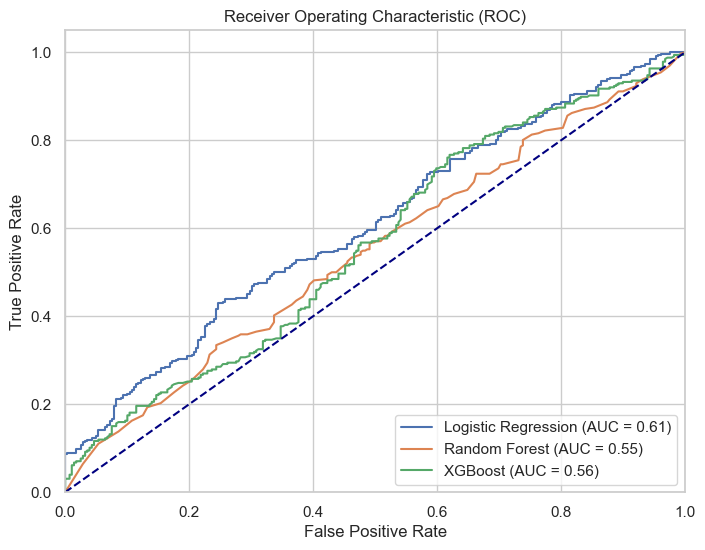

In [6]:
# Initialize Models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Train and Evaluate Models
results = {}

fig, ax = plt.subplots(figsize=(8, 6))

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"=== {name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot Formatting
ax.plot([0, 1], [0, 1], color='navy', linestyle='--')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Receiver Operating Characteristic (ROC)')
ax.legend(loc="lower right")
plt.show()


### Feature Importance Analysis
Using the **Random Forest** and **XGBoost** models, we can extract the most important features that contribute to winning a round.


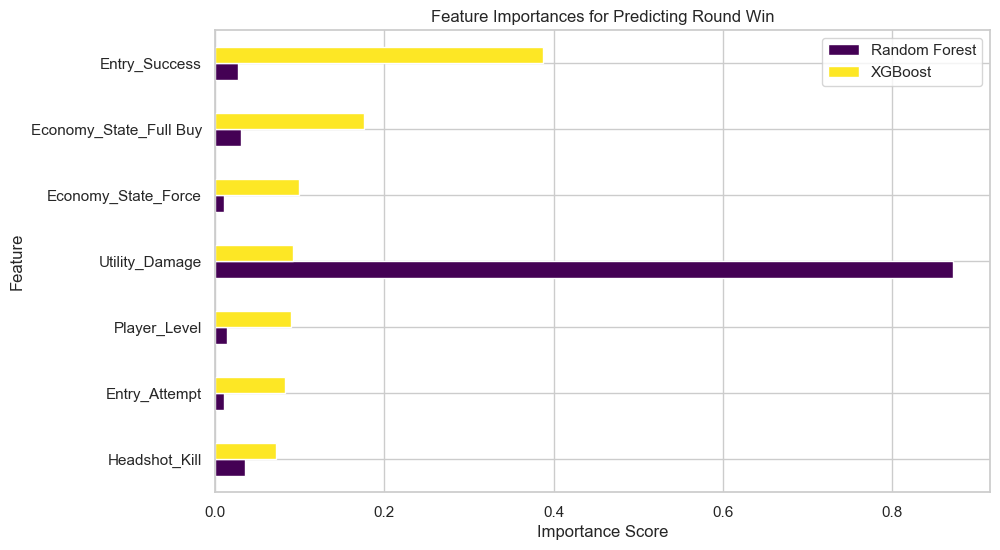

In [7]:
rf_model = models['Random Forest']
xgb_model = models['XGBoost']

# Get importances
rf_importances = rf_model.feature_importances_
xgb_importances = xgb_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Random Forest': rf_importances,
    'XGBoost': xgb_importances
}).set_index('Feature')

# Plot
importance_df.sort_values('XGBoost', ascending=True).plot(kind='barh', figsize=(10, 6), colormap='viridis')
plt.title('Feature Importances for Predicting Round Win')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()
